In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

# Exploration du dataset — IRM cérébrales pour détection de tumeurs

Analyse de la structure, des résolutions, des canaux de couleur et des exemples visuels.

In [1]:
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

random.seed(42)
DATA_DIR = Path("data")
assert DATA_DIR.exists(), f"DATA_DIR introuvable — CWD : {Path.cwd()}"

## 1. Structure du dataset

In [2]:
records = []
for img_path in DATA_DIR.rglob("*.jpg"):
    relative_parts = img_path.relative_to(DATA_DIR).parts
    if "cancer" in relative_parts:
        label, split = "cancer", "labeled"
    elif "normal" in relative_parts:
        label, split = "normal", "labeled"
    else:
        label, split = "unlabeled", "unlabeled"
    records.append({"path": img_path, "label": label, "split": split})

df = pd.DataFrame(records)
print(f"Total images : {len(df)}")
df.groupby(["split", "label"]).size().reset_index(name="count")

Total images : 1506


,split,label,count
0,labeled,cancer,50
1,labeled,normal,50
2,unlabeled,unlabeled,1406


## 2. Analyse des résolutions et canaux de couleur

In [3]:
# Analyse sur la totalité du dataset
meta = []
for _, row in df.iterrows():
    try:
        with Image.open(row["path"]) as img:
            meta.append({
                "label": row["label"],
                "width": img.size[0],
                "height": img.size[1],
                "mode": img.mode,
                "file_size_kb": round(row["path"].stat().st_size / 1024, 1),
            })
    except Exception as e:
        meta.append({"label": row["label"], "error": str(e)})

meta_df = pd.DataFrame(meta)

# Report errors explicitly
if "error" in meta_df.columns:
    errors = meta_df[meta_df["error"].notna()]
    if not errors.empty:
        print(f"AVERTISSEMENT : {len(errors)} image(s) corrompue(s) détectée(s)")
        print(errors[["label", "error"]])

meta_clean = meta_df.dropna(subset=["width"])
print(f"Images analysées : {len(meta_clean)} / {len(df)}")
print("Résolutions uniques :", meta_clean[["width", "height"]].drop_duplicates().values.tolist())
print("Modes uniques :", meta_clean["mode"].unique().tolist())
meta_clean

Images analysées : 1506 / 1506
Résolutions uniques : [[512, 512]]
Modes uniques : ['RGB']


,label,width,height,mode,file_size_kb
0,unlabeled,512,512,RGB,30.1
1,unlabeled,512,512,RGB,14.8
2,unlabeled,512,512,RGB,19.1
3,unlabeled,512,512,RGB,23.2
4,unlabeled,512,512,RGB,21.3
...,...,...,...,...,...
1501,normal,512,512,RGB,25.0
1502,normal,512,512,RGB,17.9
1503,normal,512,512,RGB,64.3
1504,normal,512,512,RGB,23.4


## 3. Exemples d'images par classe

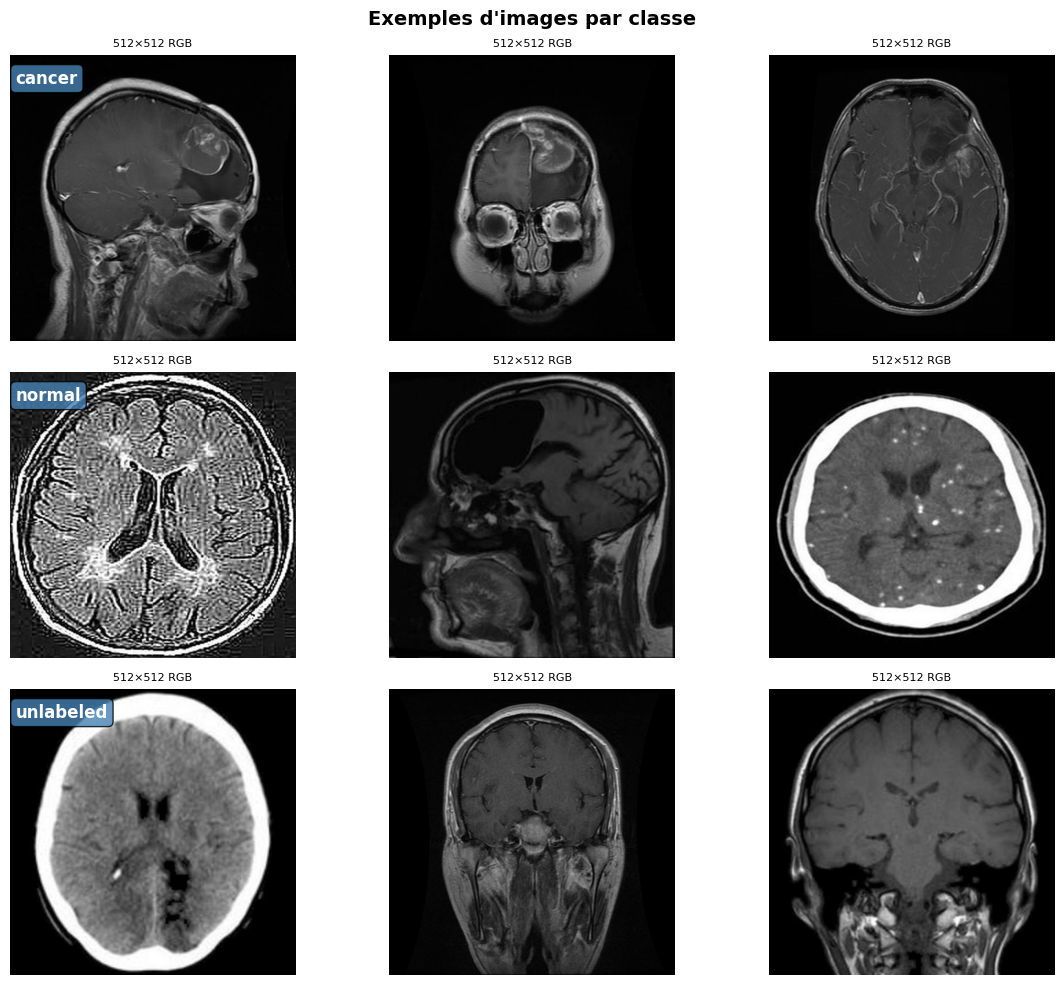

In [4]:
labels = ["cancer", "normal", "unlabeled"]
n_cols = 3
fig, axes = plt.subplots(len(labels), n_cols, figsize=(12, 10))
fig.suptitle("Exemples d'images par classe", fontsize=14, fontweight="bold")

for row_idx, label in enumerate(labels):
    subset = df[df["label"] == label]["path"].tolist()
    sample_paths = random.sample(subset, min(n_cols, len(subset)))
    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_paths):
            try:
                with Image.open(sample_paths[col_idx]) as img:
                    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
                    ax.set_title(f"{img.size[0]}×{img.size[1]} {img.mode}", fontsize=8)
            except Exception as e:
                ax.text(0.5, 0.5, "Erreur", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(str(e)[:30], fontsize=7, color="red")
        ax.axis("off")

    # Label de classe en texte dans la première image
    axes[row_idx][0].text(
        0.02, 0.95, label,
        transform=axes[row_idx][0].transAxes,
        fontsize=12, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="steelblue", alpha=0.8)
    )

plt.tight_layout()
plt.show()

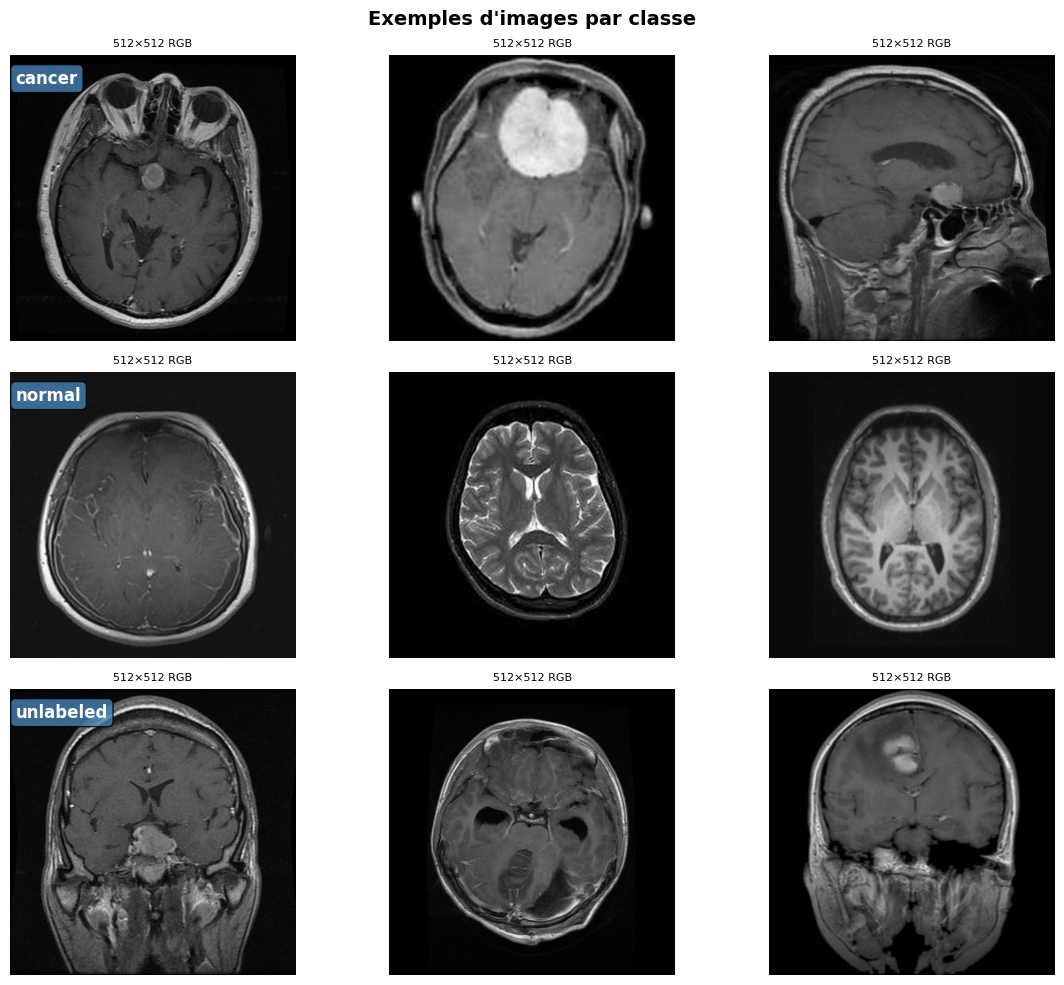

In [5]:
labels = ["cancer", "normal", "unlabeled"]
n_cols = 3
fig, axes = plt.subplots(len(labels), n_cols, figsize=(12, 10))
fig.suptitle("Exemples d'images par classe", fontsize=14, fontweight="bold")

for row_idx, label in enumerate(labels):
    subset = df[df["label"] == label]["path"].tolist()
    sample_paths = random.sample(subset, min(n_cols, len(subset)))
    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_paths):
            try:
                with Image.open(sample_paths[col_idx]) as img:
                    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
                    ax.set_title(f"{img.size[0]}×{img.size[1]} {img.mode}", fontsize=8)
            except Exception as e:
                ax.text(0.5, 0.5, "Erreur", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(str(e)[:30], fontsize=7, color="red")
        ax.axis("off")

    # Label de classe en texte dans la première image
    axes[row_idx][0].text(
        0.02, 0.95, label,
        transform=axes[row_idx][0].transAxes,
        fontsize=12, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="steelblue", alpha=0.8)
    )

plt.tight_layout()
plt.show()

## 4. Distribution des tailles de fichiers

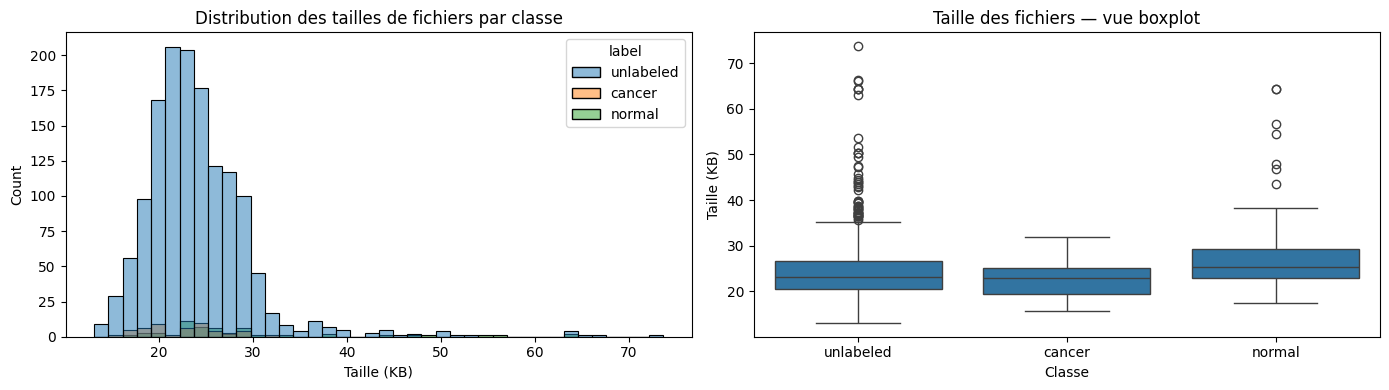

Seuils IQR : [11.5 KB — 35.8 KB]
Fichiers trop petits ? : 0
Fichiers trop grands ? : 56


In [6]:
df["file_size_kb"] = df["path"].apply(lambda p: round(p.stat().st_size / 1024, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=df, x="file_size_kb", hue="label", bins=40, ax=axes[0])
axes[0].set_title("Distribution des tailles de fichiers par classe")
axes[0].set_xlabel("Taille (KB)")

sns.boxplot(data=df, x="label", y="file_size_kb", ax=axes[1])
axes[1].set_title("Taille des fichiers — vue boxplot")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Taille (KB)")

plt.tight_layout()
plt.show()

# Outliers via IQR (les deux côtés)
q1 = df["file_size_kb"].quantile(0.25)
q3 = df["file_size_kb"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers_small = df[df["file_size_kb"] < lower_bound]
outliers_large = df[df["file_size_kb"] > upper_bound]

print(f"Seuils IQR : [{lower_bound:.1f} KB — {upper_bound:.1f} KB]")
print(f"Fichiers trop petits ? : {len(outliers_small)}")
print(f"Fichiers trop grands ? : {len(outliers_large)}")

outliers = pd.concat([outliers_small, outliers_large])


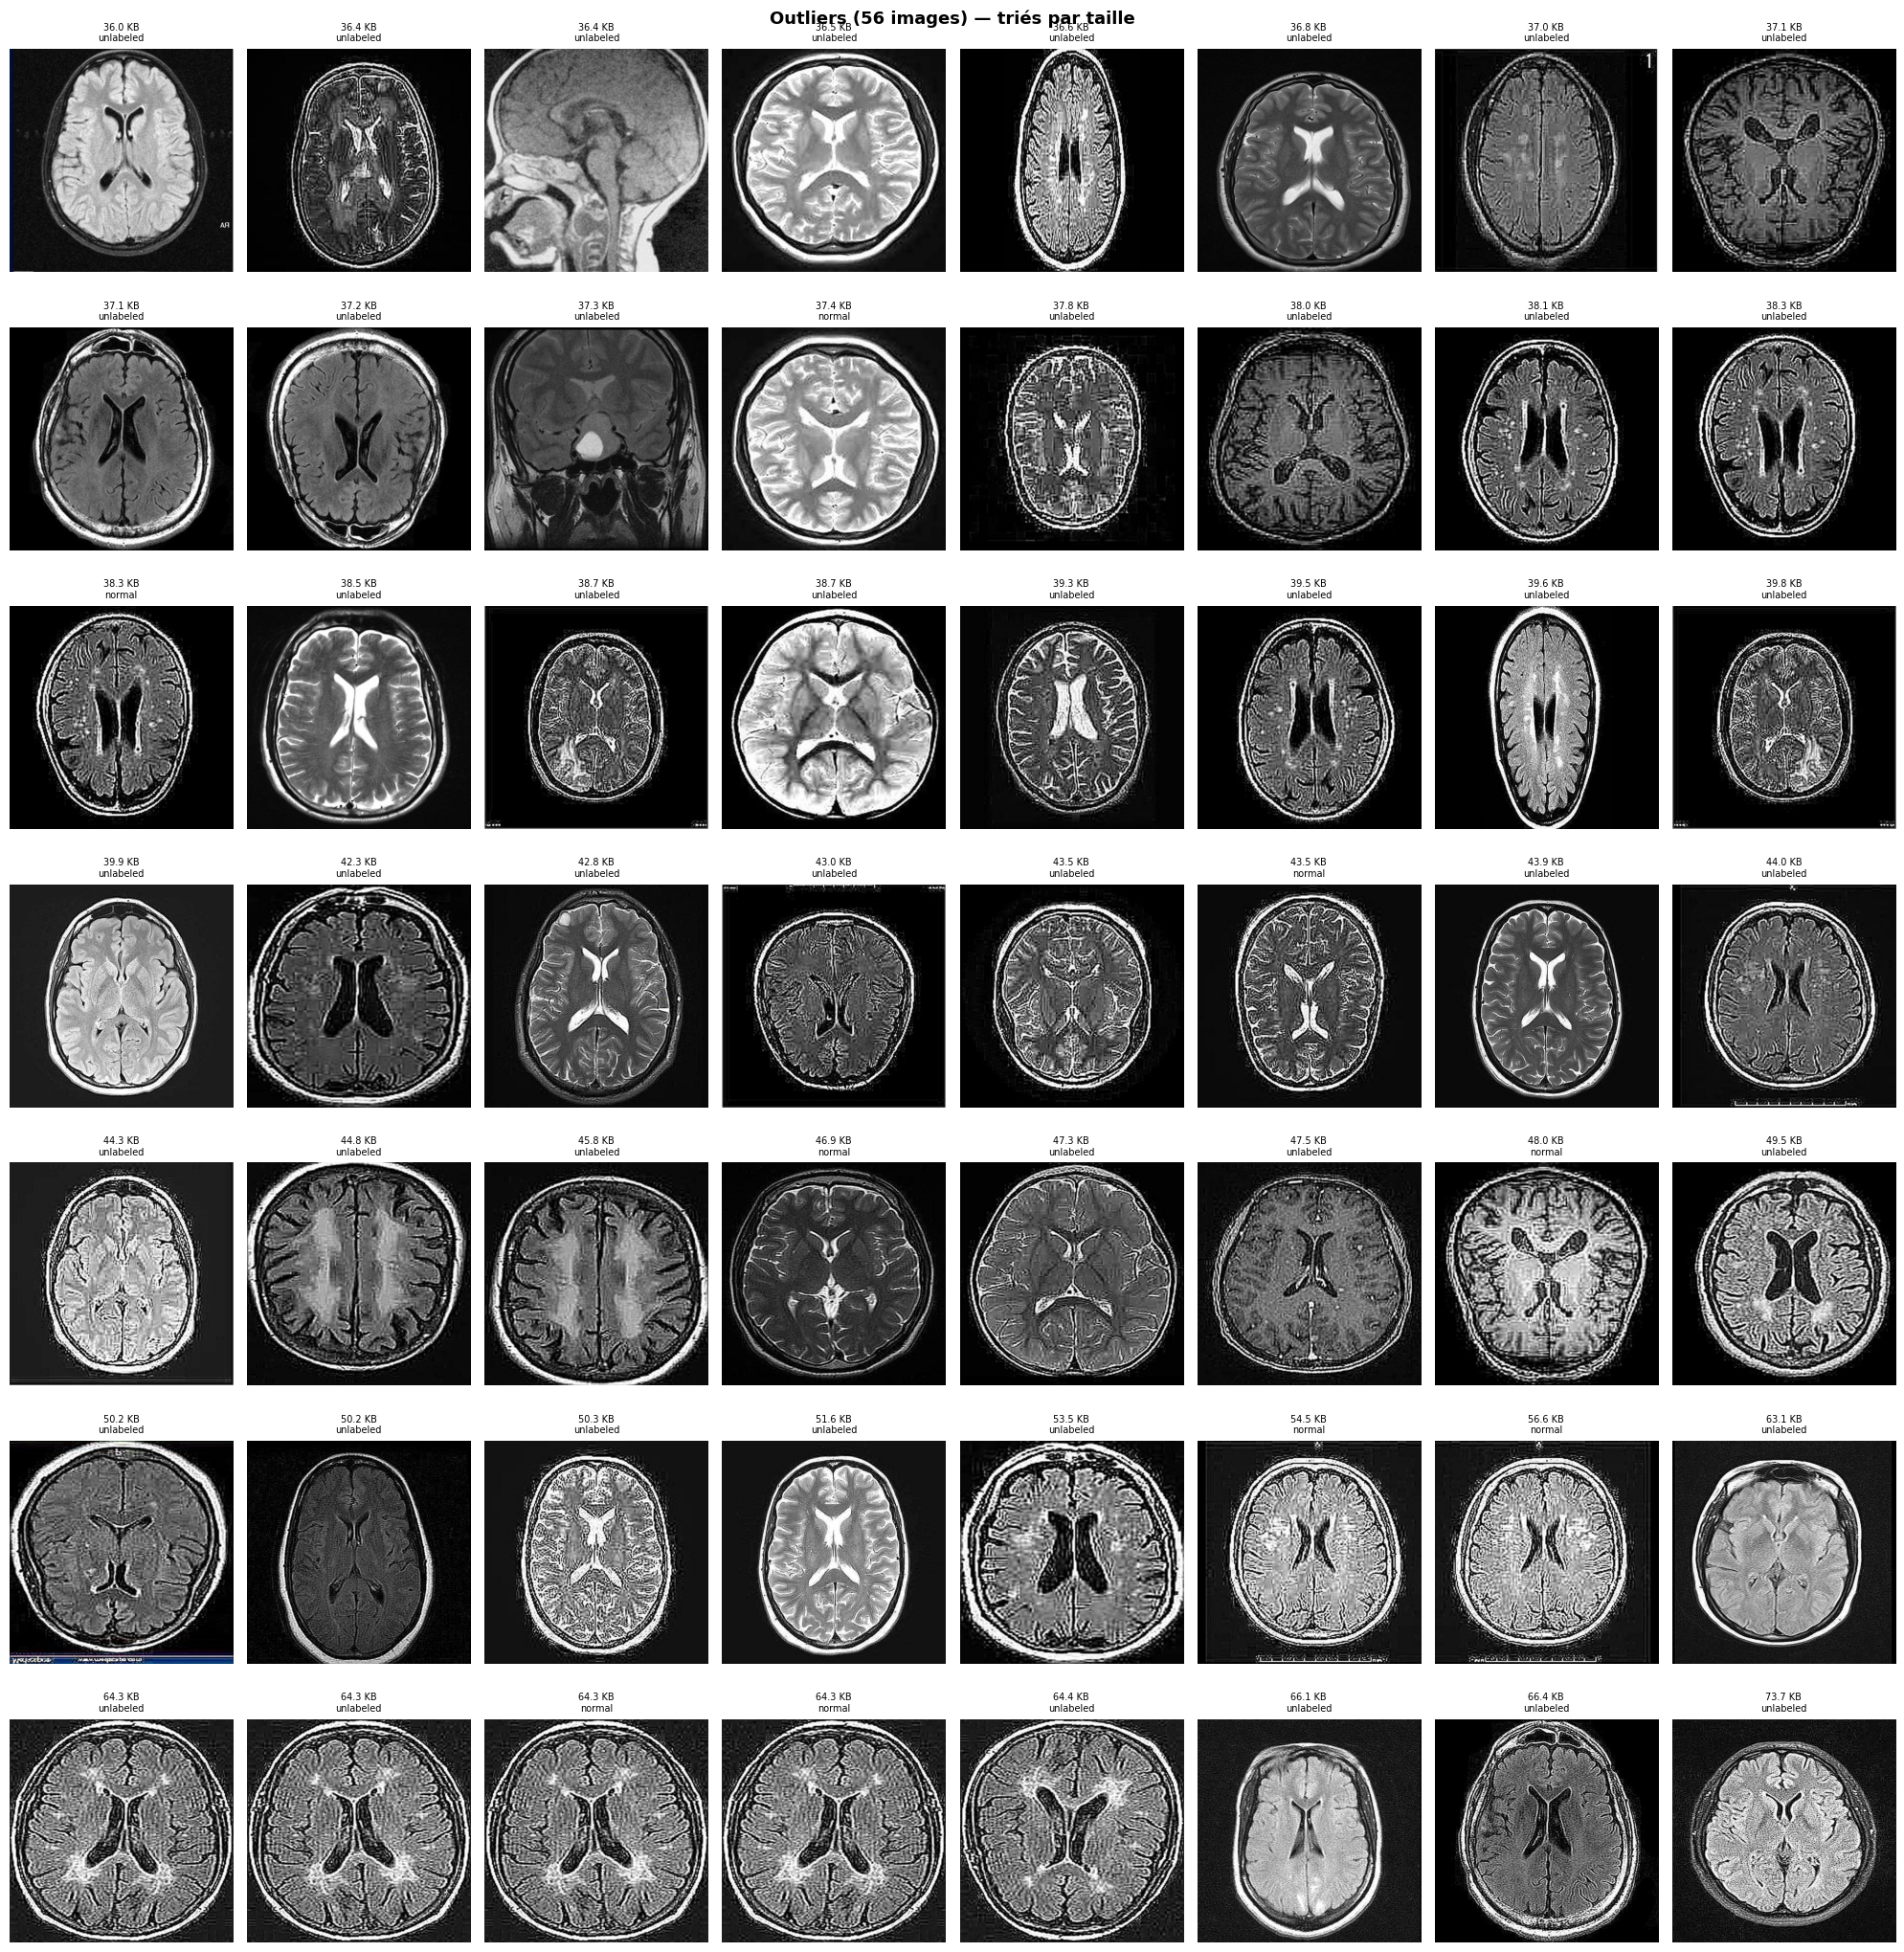

In [7]:
# Display all outlier images
if not outliers.empty:
    n = len(outliers)
    n_cols = 8
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    axes = axes.flatten()

    for i, (_, row) in enumerate(outliers.sort_values("file_size_kb").iterrows()):
        try:
            with Image.open(row["path"]) as img:
                axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, "Erreur", ha="center", va="center", transform=axes[i].transAxes)
        axes[i].set_title(f"{row['file_size_kb']} KB\n{row['label']}", fontsize=7)
        axes[i].axis("off")

    # Masquer les axes vides
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Outliers ({n} images) — triés par taille", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()